## STOCHASTIC MODELING
MODULE 1 | LESSON 2


---


# **OPTION PRICING UNDER HESTON (MONTE CARLO)**


|  |  |
|:---|:---|
|**Reading Time** |  70 minutes |
|**Prior Knowledge** | Black-Scholes, Heston, Stochastic volatility  |
|**Keywords** | Monte Carlo, Heston, Black-Scholes |


---


In the last lesson we introduced an important concept, **stochastic volatility**, which takes us one step forward in our quest to get to a model that captures empirical stylized facts. So, how can we price derivatives using models of stochastic volatility such Heston (1993)?

In this lesson, we will **implement Monte-Carlo pricing** of an option **under Heston model dynamics**.*

## **1. Option Pricing under more Complex Models**

At this point, you should have already realized that the hard part of option pricing is in the underlying asset price dynamics: once we have assumed some **risk-neutral** behavior for the underlying asset, the price of the option is merely its discounted expected payoff:

- If we are lucky, there may exist a **closed-form solution** to the price of the option (e.g., Black-Scholes).

- The latter is not going to be the case with more complex models, but there is always the option to use **Monte-Carlo methods** to simulate the expected option payoff under certain underlying dynamics. This is precisely what we show in this lesson.

\
We do know how to use Monte-Carlo methods to create underlying asset price paths under certain dynamics, e.g. Heston (1993). But there is an implicit problem we have overlooked so far:

- **How do we obtain the parameters of the Heston (1993) model ($\kappa$, $\theta$, $\sigma$, ...)?**

For now, we are going to take these parameters as *magically given to us*, but this is one of the largest problems we face when pricing and hedging derivatives. We will talk deep about this in the upcoming modules, let's now focus on how would we operate once we have obtained these parameters...

In [1]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1116720074", h="3298dbabb7", width=700, height=450)



## **2. Pricing under Heston Using Monte-Carlo Methods**

As you can expect, we will be first replicating the code used in the last lesson on how to simulate underlying stock prices under the following Heston dynamics:
$$
\begin{equation*}
    S_t = S_{t-1} e^{\left( r - \frac{\nu_t}{2} \right) dt + \sigma \sqrt{\nu_t} dZ_1}
\end{equation*}
$$
$$
\begin{equation*}
    \nu_t = \nu_{t-1} + \kappa \left( \theta - \nu_{t-1} \right) dt + \sigma \sqrt{\nu_{t-1}}dZ_2
\end{equation*}
$$
\
So, let's define and run the different functions we needed to simulate stock prices:

- First, libraries and **stochastic volatility**:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss

In [3]:
def SDE_vol(v0, kappa, theta, sigma, T, M, I, rand, row, cho_matrix):
    dt = T / M  # T = maturity, M = number of time steps
    v = np.zeros((M + 1, I), dtype=float)
    v[0] = v0
    sdt = np.sqrt(dt)  # Sqrt of dt
    for t in range(1, M + 1):
        ran = np.dot(cho_matrix, rand[:, t])
        v[t] = np.maximum(0, v[t - 1] + kappa * (theta - v[t - 1]) * dt + np.sqrt(v[t - 1]) * sigma * ran[row] * sdt)
    return v

- Second, **underlying stock price** path based on stochastic vol:

In [4]:
def Heston_paths(S0, r, v, row, cho_matrix):
    S = np.zeros((M+1, I), dtype=float)
    S[0] = S0
    sdt = np.sqrt(dt)
    for t in range(1, M+1, 1):
        ran = np.dot(cho_matrix, rand[:,t])
        S[t] = S[t - 1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * ran[row] * sdt)

    return S

- Third, our function to **generate random numbers** following a standard normal:

In [5]:
def random_number_gen(M, I):
    rand = np.random.standard_normal((2, M+1, I))
    return rand

We have already discussed one of the main problems we will encounter when using Heston is how to set up the different parameters needed by the model. We will spend a lot of time unveiling this in the next modules. For now, let's assume some given parameters:

In [6]:
v0 = 0.095
kappa_v = 5
sigma_v = 0.35
theta_v = 0.1
rho = 0.25

S0 = 40.53  # Current underlying asset price
r = 0.05  # Risk-free rate
M0 = 500   # Number of time steps in a year
T = 12/12  # Number of years
M = int(M0*T) # Total time steps
I = 20000  # Nomber of simulations
dt = T/M  # Length of time step

np.random.seed(42)

And build our covariance matrix (using Cholesky decomposition to account for correlation between $dZ_1$ and $dZ_2$):

In [7]:
# Generating random numbers from standard normal
rand = random_number_gen(M, I)


# Covariance Matrix
covariance_matrix = np.zeros((2, 2))
covariance_matrix[0] = [1.0, rho]
covariance_matrix[1] = [rho, 1.0]
cho_matrix = np.linalg.cholesky(covariance_matrix)

We can now simulate the stock price paths and stochastic volatility:

In [8]:
# Volatility process paths
V = SDE_vol(v0, kappa_v, theta_v, sigma_v, T, M, I, rand, 1, cho_matrix)

# Underlying price process paths
S = Heston_paths(S0, r, V, 0, cho_matrix)

and visulize them:

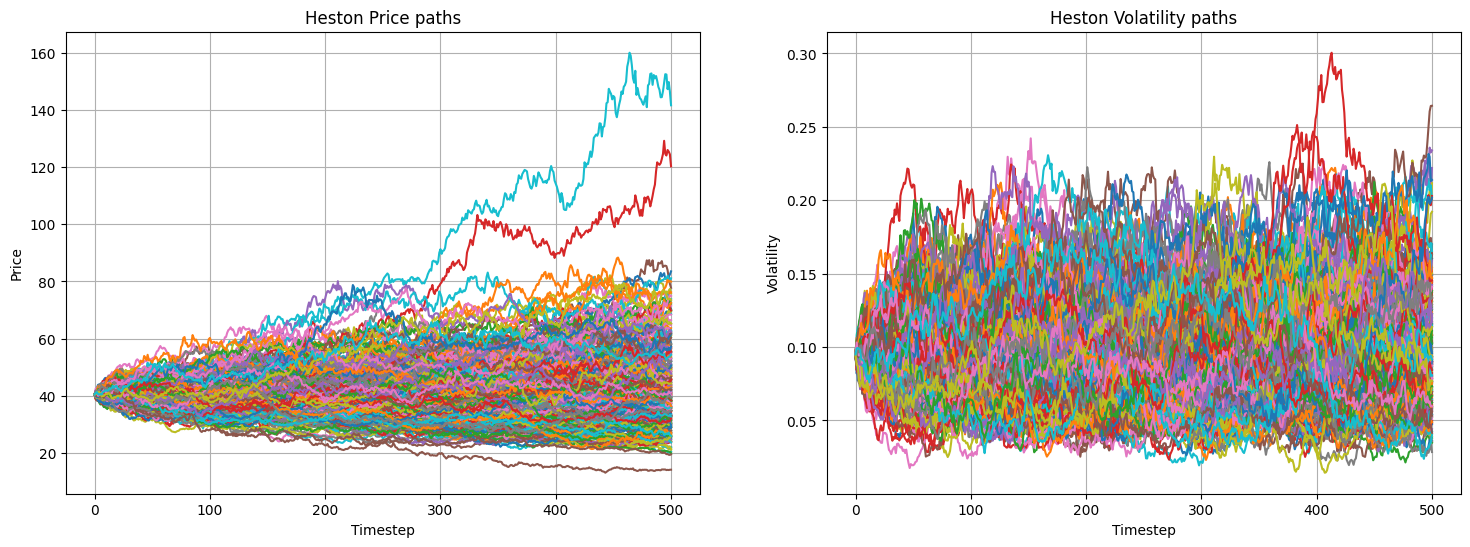

In [9]:
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(300)

Now that we have simulated all the stock prices under Heston, let's define another function that calculates the payoffs and current price of a European call option with the following characteristics:

- $T=1$ year
- $K = 39$
- $r=0.05$
- $S_t \sim$ Heston dynamics

The price of the Call option will be given by:

$$
C_0 = e^{-rT}E\left( S_T - K \right)^+
$$

which, using Monte-Carlo, we can code into:

In [10]:
def heston_call_mc(S, K, r, T, t):
    payoff = np.maximum(0, S[-1, :] - K)

    average = np.mean(payoff)

    return np.exp(-r * (T - t)) * average

Note that you can improve the efficiency of the previous function substantially by implementing a better and more organized function that incorporates the generation of stock price and volatility paths. We recommend you work on this by yourself (it should be fairly easy) in order to work on Group Work Projects and other tasks. At this point, we just want to highlight how we apply the spirit of the Monte-Carlo method in simpler frameworks.

\
So, the price of a European Call option with 1 year maturity and strike $K=90$ (and all the other assumed parameters from before) is...

In [11]:
print("European Call Price under Heston: ", heston_call_mc(S, 39, r, T, 0))

European Call Price under Heston:  6.74996009050462


In [12]:
import numpy as np

In [13]:
import numpy as np

# def heston_call_mc(
#     S0, K, r, T,
#     v0, kappa, theta, sigma, rho,
#     n_steps=252, n_paths=100_000,
#     q=0.0, seed=None,
#     return_paths=False
# ):

#     dt = T / n_steps
#     sqrt_dt = np.sqrt(dt)
#     rng = np.random.default_rng(seed)

#     # Only keep current values unless full paths are requested
#     S = np.full(n_paths, S0, dtype=np.float64)
#     v = np.full(n_paths, v0, dtype=np.float64)

#     if return_paths:
#         S_paths = np.empty((n_steps + 1, n_paths), dtype=np.float64)
#         v_paths = np.empty((n_steps + 1, n_paths), dtype=np.float64)
#         S_paths[0] = S
#         v_paths[0] = v

#     # Precompute constant
#     rho_comp = np.sqrt(1.0 - rho**2)

#     for t in range(1, n_steps + 1):
#         z1 = rng.standard_normal(n_paths)
#         z2 = rng.standard_normal(n_paths)

#         # Correlated Brownian increments
#         dW_v = sqrt_dt * z1
#         dW_s = sqrt_dt * (rho * z1 + rho_comp * z2)

#         # Full truncation Euler to help preserve non-negativity
#         v_pos = np.maximum(v, 0.0)

#         # Variance update
#         v = v + kappa * (theta - v_pos) * dt + sigma * np.sqrt(v_pos) * dW_v
#         v = np.maximum(v, 0.0)

#         # Stock update
#         S *= np.exp((r - q - 0.5 * v_pos) * dt + np.sqrt(v_pos) * dW_s)

#         if return_paths:
#             S_paths[t] = S
#             v_paths[t] = v

#     payoff = np.maximum(S - K, 0.0)
#     discounted_payoff = np.exp(-r * T) * payoff

#     price = np.mean(discounted_payoff)
#     stderr = np.std(discounted_payoff, ddof=1) / np.sqrt(n_paths)

#     if return_paths:
#         return price, stderr, S_paths, v_paths

#     return price, stderr

## 🔧 Code Task 1.1: Price a European Put Option under the Heston Model

You’ve already seen how to price a **European Call Option** using Monte Carlo simulations under the Heston model dynamics. Now, it’s your turn to implement the pricing logic for a **European Put Option**.

### 🎯 Your Task:
Create a function `heston_put_mc(S, K, r, T, t)` that returns the price of a European **put option** using the final simulated stock prices `S` from the Heston model.

### 🧩 Inputs:
- `S`: A NumPy array with shape `(T+1, I)` containing simulated Heston stock price paths  
- `K`: Strike price  
- `r`: Constant risk-free rate  
- `T`: Maturity (in years)  
- `t`: Current time (use `t = 0`)

### 📌 Instructions:
- Use the final prices `S[-1, :]` to compute the payoff of a **put option**.
- The payoff is `max(K - S_T, 0)`  
- Take the average payoff across all paths and discount it to present value using the risk-free rate.
- Return the final discounted price.

### 🧪 Example Call:
```python
print("European Put Price under Heston: ", heston_put_mc(S, 39, r, T, 0))




In [15]:
# Starter Code: Implement European Put Option Pricing under Heston

def heston_put_mc(S, K, r, T, t):
    """
    Monte Carlo pricing of a European Put Option under Heston model.

    Parameters:
    - S: Simulated stock price paths (shape: [T+1, I])
    - K: Strike price
    - r: Risk-free interest rate
    - T: Maturity
    - t: Current time (typically 0)

    Returns:
    - Present value of the expected put payoff
    """
    

    # TODO: 1. Extract the final prices from the simulation
    S_T = S[-1:]
    
    # TODO: 2. Compute put payoffs: max(K - S_T, 0)
    payoff = np.maximum(K-S_T,0)
    # TODO: 3. Take the average payoff across all paths
    average_payoff = np.mean(payoff)
    # TODO: 4. Discount the average payoff to present value
    put_price = np.exp(-r*(T-t))*average_payoff

    return put_price  # Replace with your implementation


# Example usage (S must be previously simulated):
print("European Put Price under Heston: ", heston_put_mc(S, 39, r, T, 0))


European Put Price under Heston:  3.3076974519290814


## **3. Comparison of Heston Option Price versus Other Methods**

Let's now see how the value of the option via Heston model differs from what we would have under the Black-Scholes framework, for example.

- **Black-Scholes closed-form solution**:

In [17]:
def bs_call_price(S, r, sigma, t, T, K):
    ttm = T - t

    if ttm < 0:
        return 0.0
    elif ttm == 0.0:
        return np.maximum(S - K, 0.0)

    vol = sigma * np.sqrt(ttm)

    d_minus = np.log(S / K) + (r - 0.5 * sigma**2) * ttm
    d_minus /= vol

    d_plus = d_minus + vol

    res = S * ss.norm.cdf(d_plus)
    res -= K * np.exp(-r * ttm) * ss.norm.cdf(d_minus)

    return res

In [18]:
print("European Call Price under BS: ", bs_call_price(S0, r, sigma_v, 0, 1, 39))

European Call Price under BS:  7.277585553784192


- **Black-Scholes Monte-Carlo price:**

In [19]:
def bs_call_mc(S, K, r, sigma, T, t, Ite):
    data = np.zeros((Ite, 2))
    z = np.random.normal(0, 1, [1, Ite])
    ST = S * np.exp((T - t) * (r - 0.5 * sigma**2) + sigma * np.sqrt(T - t) * z)
    data[:, 1] = ST - K

    average = np.sum(np.amax(data, axis=1)) / float(Ite)

    return np.exp(-r * (T - t)) * average

In [20]:
print(
    "European Call Price under BS (MC): ",
    bs_call_mc(S0, 39, r, sigma_v, 1, 0, 10000))

European Call Price under BS (MC):  7.274840872838278


Interestingly, we get prices under the two models that are away from each other.

- **Is this a problem? Does our model not work?**

Well, it definitely is **an issue**, because we are comparing apples to oranges, as we are taking parameter values for each of the models that are almost  as good as random! (i.e., should $\sigma$ in BS and Heston be the same? likely not, as there are other parameters influencing asset dynamics!)

- **Should we expect exactly the same prices from BS and Heston?**

Of course not! If we got the same price with a simple and a complex model, what's the point of employing the complex one? Heston (and other complex models) are just **extending the BS world** to get closer to reality.

The whole point is that complex models, more difficult and computationally costlier to implement, will give us a more accurate pricing and hedging for our derivatives. This seems to be the supported by the dynamics produced by these models, which are closer to real-life ones: when you look at Lesson 1 and the statistical distribution under Heston. There is more kurtosis and skewness than normal distribution, just as we observe in practice.

## **4. Conclusion**

In this lesson, we have advanced our understanding towards more complex models that try to capture the different features associated with underlying stock prices and returns. From Black-Scholes to the Heston model, we have focused on modeling the underlying asset dynamics and pricing derivative instruments under Monte-Carlo given certain asset price evoluation.

In the next lesson, we will focus on one more stylized fact of stock prices: jumps.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.